In [520]:
import pandas as pd

df = pd.read_csv('df_labeled_all_final_25.csv')
df.shape

(37569, 20)

In [521]:
df['gender_accused'].value_counts()

gender_accused
1    31588
0     5981
Name: count, dtype: int64

In [522]:
df['prior_convictions'].value_counts()

prior_convictions
0    31891
1     5678
Name: count, dtype: int64

In [523]:
df['alcohol'].value_counts()

alcohol
1    31641
0     5928
Name: count, dtype: int64

In [524]:
df['precrime_argument'].value_counts()

precrime_argument
1    34549
0     3020
Name: count, dtype: int64

In [525]:
df['has_woman_victim'].value_counts()

has_woman_victim
0    25571
1    11998
Name: count, dtype: int64

In [526]:
df['has_man_victim'] = df['has_man_victim'].astype(int)

In [527]:
df['has_man_victim'].value_counts()

has_man_victim
1    29642
0     7927
Name: count, dtype: int64

In [528]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')

In [529]:
df['method'].value_counts()

method
холодное оружие                                                                              18570
физическое воздействие, холодное оружие                                                       8639
физическое воздействие                                                                        1993
огнестрельное оружие                                                                          1803
тяжелые предметы, физическое воздействие                                                      1498
удушение, физическое воздействие                                                              1214
другое                                                                                        1058
тяжелые предметы                                                                               699
удушение                                                                                       688
тяжелые предметы, физическое воздействие, холодное оружие                                      382
тяж

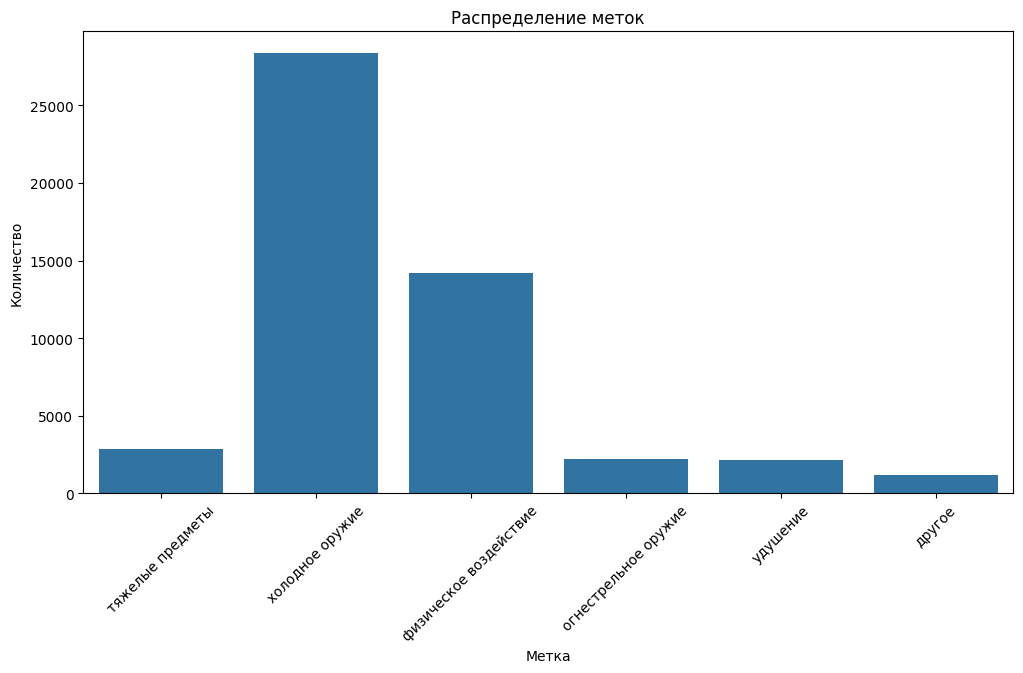

In [530]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


df['method1'] = df['method'].str.split(", ")

labels = df['method1'].tolist()
label_counts = Counter([label for sublist in labels for label in sublist])

plt.figure(figsize=(12, 6))
sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
plt.title("Распределение меток")
plt.xlabel("Метка")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.show()

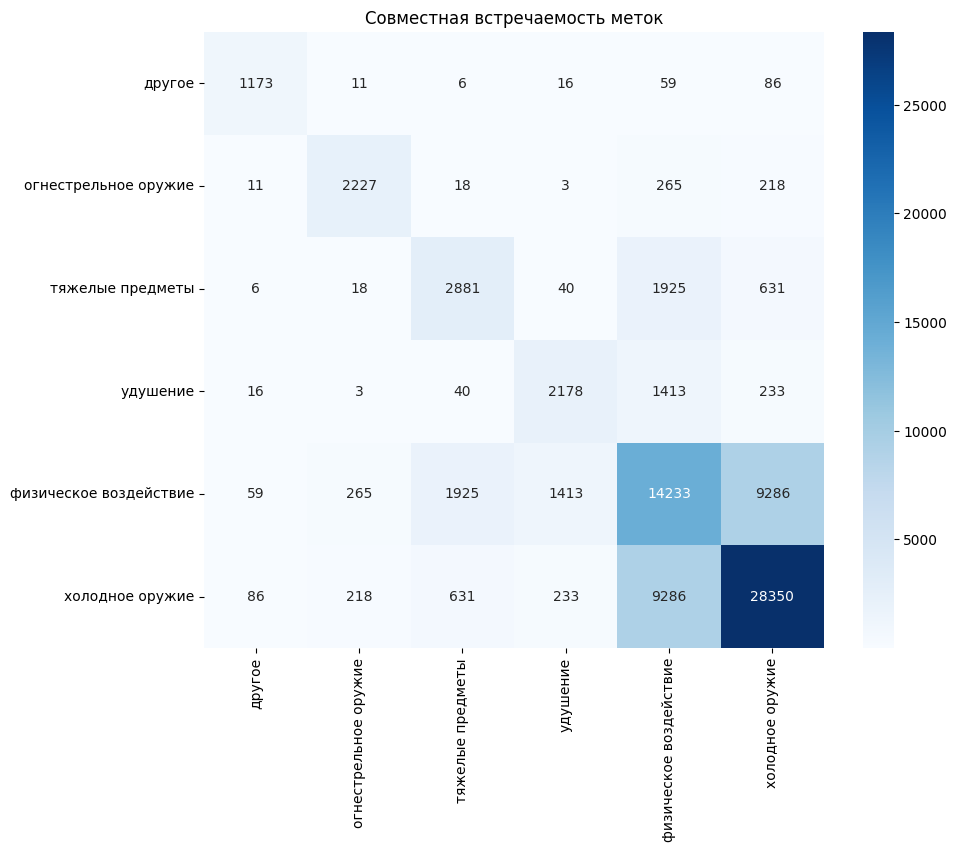

In [531]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(labels)

co_occurrence = binary_labels.T @ binary_labels

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="Blues", 
            xticklabels=mlb.classes_, yticklabels=mlb.classes_)
plt.title("Совместная встречаемость меток")
plt.show()

In [532]:
# from sklearn.preprocessing import MultiLabelBinarizer

# result_df = pd.DataFrame(columns=['Column', 'Class', 'Mean Prison Term'])

# for col in ['method']:

#     mlb = MultiLabelBinarizer()
#     col_binarized = mlb.fit_transform(df[col])
#     col_df = pd.DataFrame(col_binarized, columns=mlb.classes_)

#     col_df.index = df.index
#     df = pd.concat([df, col_df], axis=1).drop(col, axis=1)

#     for class_name in mlb.classes_:
#         mean_term = df.loc[df[class_name] == 1, 'prison_term'].mean()
#         result_df = pd.concat([result_df, pd.DataFrame({
#             'Column': [col],
#             'Class': [class_name],
#             'Mean Prison Term': [mean_term],
#             'Count': [df[class_name].sum()]
#         })], ignore_index=True)

# result_df = result_df.sort_values(by='Mean Prison Term', ascending=False)
# result_df['Mean Prison Term'] = result_df['Mean Prison Term'].round(2)
# result_df = result_df.reset_index(drop=True)

# print("\nСредние сроки по классам:")
# print(result_df.to_string(index=False))

In [533]:
categorical = ['judge', 'decision', 'season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

In [534]:
categorical = ['judge', 'decision', 'season', 'region_name']
numeric = ['year']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

In [535]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df

In [536]:
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()

year
2016          6090
2017          5894
2018          4935
2020          4446
2021          4293
2019          4172
2022          4031
2023          2380
другое год    1328
Name: count, dtype: int64

In [537]:
# for label in mlb.classes_:
#     for categorical_feature in ['season', 'region_name']:
#         grouped = df.groupby(categorical_feature)[label].mean().reset_index()

#         plt.figure(figsize=(20, 6))
#         sns.barplot(x=categorical_feature, y=label, data=grouped)
#         plt.title(f"Доля метки '{label}' по категории '{categorical_feature}'")
#         plt.show()

In [538]:
multilabel

['method', 'motive', 'location']

In [539]:
df['method'].value_counts()

method
холодное оружие                                                                              18570
физическое воздействие, холодное оружие                                                       8639
физическое воздействие                                                                        1993
огнестрельное оружие                                                                          1803
тяжелые предметы, физическое воздействие                                                      1498
удушение, физическое воздействие                                                              1214
другое                                                                                        1058
тяжелые предметы                                                                               699
удушение                                                                                       688
тяжелые предметы, физическое воздействие, холодное оружие                                      382
тяж

In [540]:
df['motive'].value_counts()

motive
личная неприязнь                                        34688
корысть, личная неприязнь                                 935
корысть                                                   610
другое                                                    468
личная неприязнь, ревность                                310
                                                        ...  
личная неприязнь, аморальность поведения потерпевшей        1
конфликт, личная неприязнь                                  1
ревность, корысть                                           1
национальная ненависть                                      1
аморальность, противоправность                              1
Name: count, Length: 117, dtype: int64

In [541]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'другое'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
другое                                    488
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
прочее                                     22
аморальность, личная неприязнь             16
аморальность                               12
месть                                      12
корысть, месть                              7
личная неприязнь, насилие                   4
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, месть, ревность           3
корысть, личная неприязнь, месть            3
личная неприязнь, прочее                    3
аморальность, месть                         1
корысть, ревность                           1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [542]:
df['location'].value_counts()

location
жилое помещение                                                                                                                        27891
уличное пространство                                                                                                                    4430
жилое помещение, уличное пространство                                                                                                   1545
другое                                                                                                                                  1225
жилое помещение, подъезд и прилегающие зоны                                                                                              489
общественное место                                                                                                                       408
подъезд и прилегающие зоны                                                                                                               394
обще

In [543]:
df.isna().sum()

id                          0
judge                       0
decision                    0
gender_accused              0
prior_convictions           0
alcohol                     0
precrime_argument           0
has_woman_victim            0
has_man_victim              0
method                      0
motive                      0
location                    0
prison_term                 0
many_victims                0
year                        0
season                      0
attempt                     0
victim_child_or_helpless    0
cruel                       0
region_name                 0
method1                     0
dtype: int64

In [544]:
from sklearn.preprocessing import MultiLabelBinarizer

for col in multilabel:
    df[col] = df[col].str.split(", ")
    
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])

    col_df = pd.DataFrame(col_binarized, columns=[f"{col}_{cls}" for cls in mlb.classes_], index=df.index)

    df = pd.concat([df, col_df], axis=1)
    df = df.drop(columns=[col])

In [545]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'method1',
       'method_другое', 'method_огнестрельное оружие',
       'method_тяжелые предметы', 'method_удушение',
       'method_физическое воздействие', 'method_холодное оружие',
       'motive_алкоголь/наркотики', 'motive_аморальность', 'motive_другое',
       'motive_корысть', 'motive_личная неприязнь', 'motive_месть',
       'motive_насилие', 'motive_прочее', 'motive_ревность', 'location_другое',
       'location_жилое помещение', 'location_общественное место',
       'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object')

In [546]:
mlb1 = MultiLabelBinarizer()
col_binarized = mlb1.fit_transform(df['method1'])
mlb1.classes_

array(['другое', 'огнестрельное оружие', 'тяжелые предметы', 'удушение',
       'физическое воздействие', 'холодное оружие'], dtype=object)

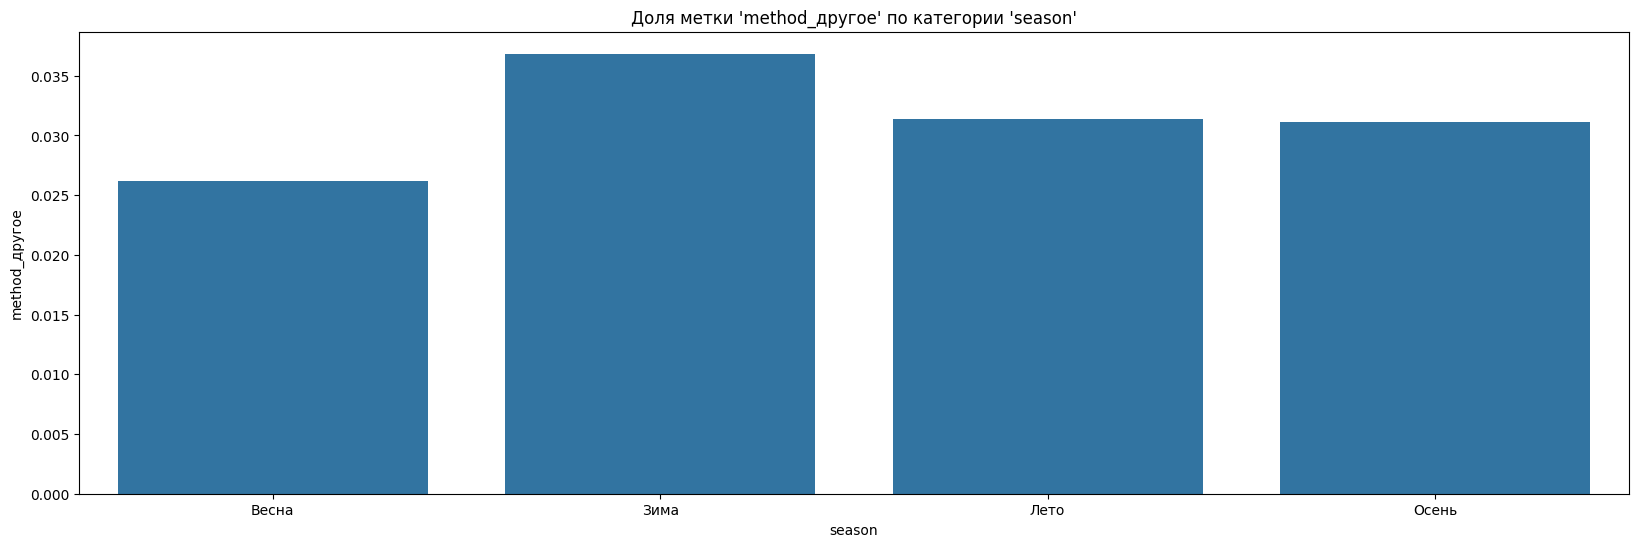

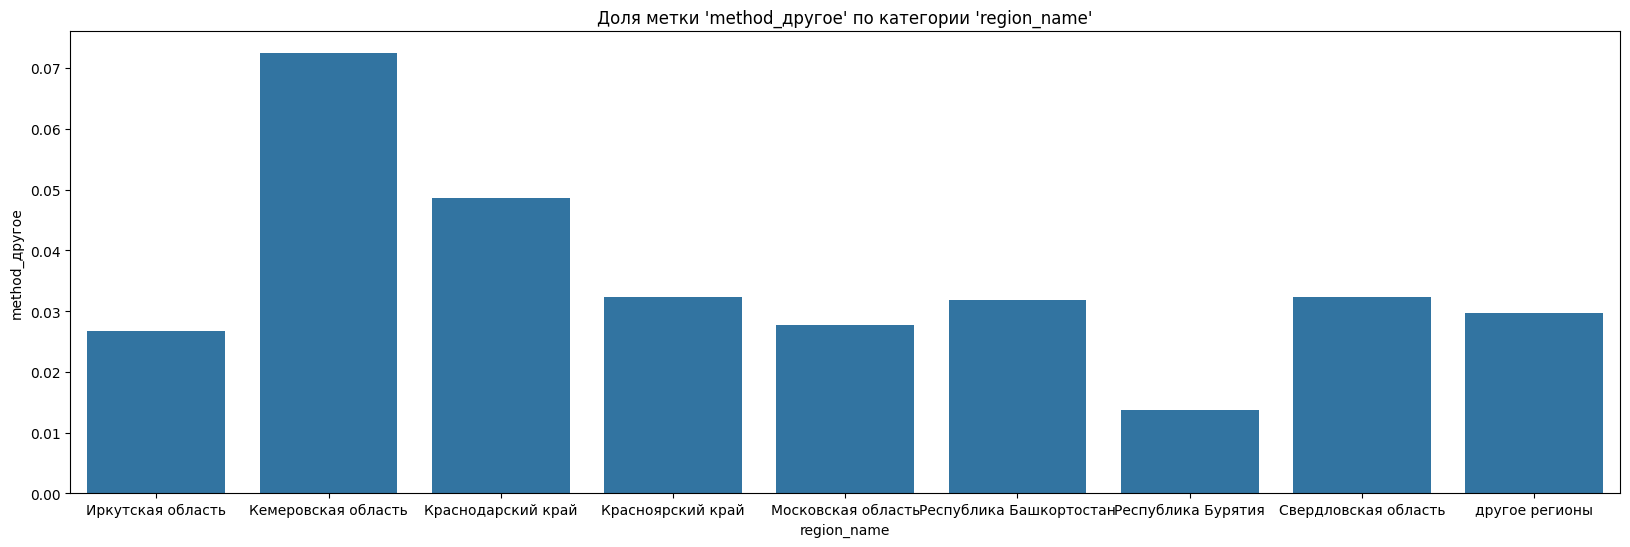

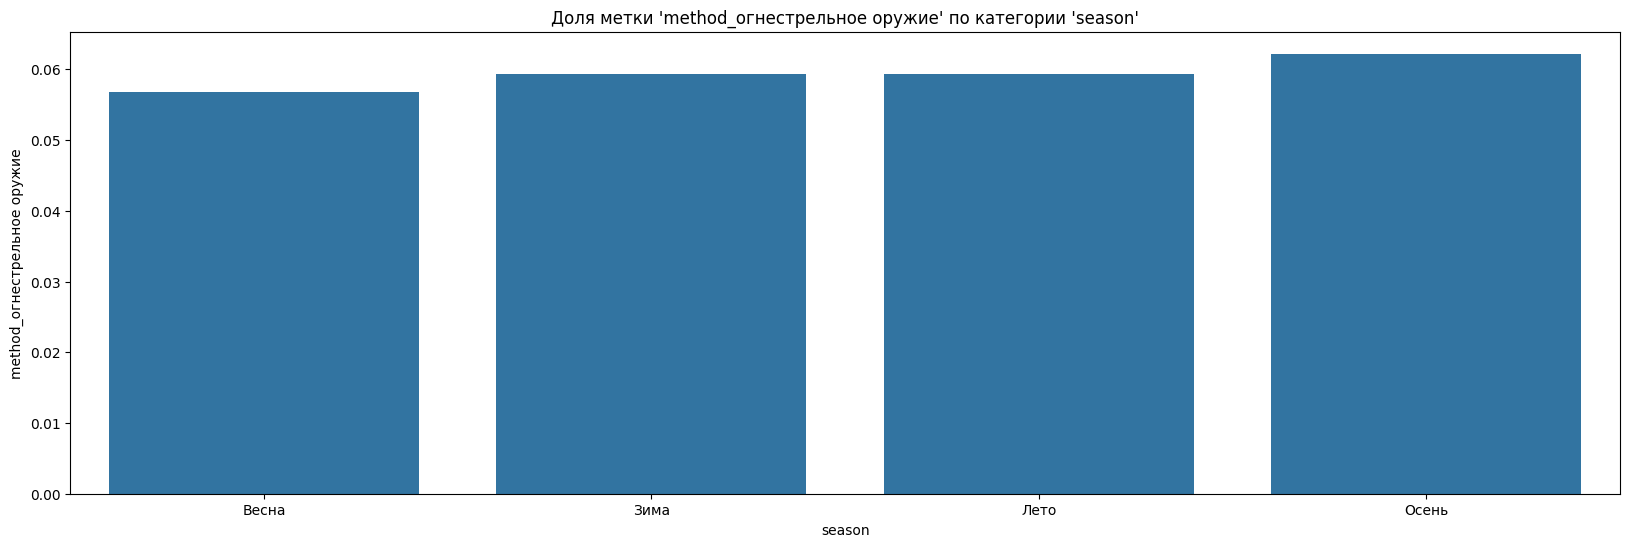

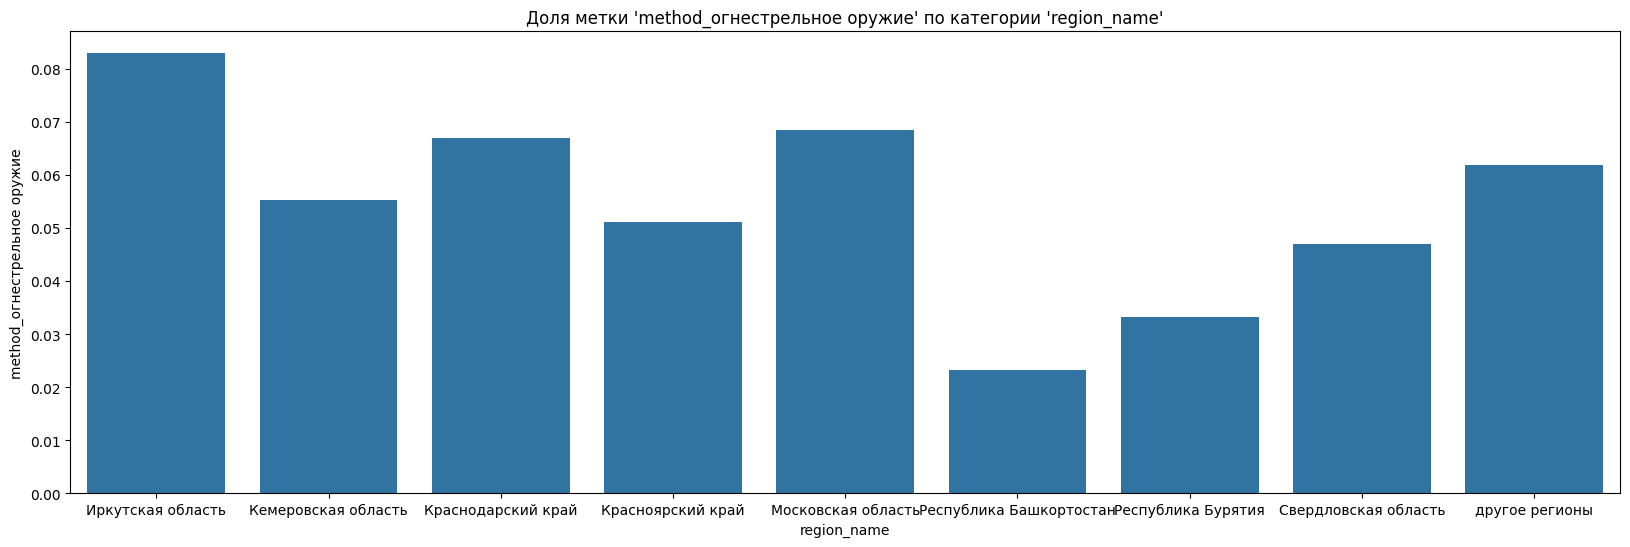

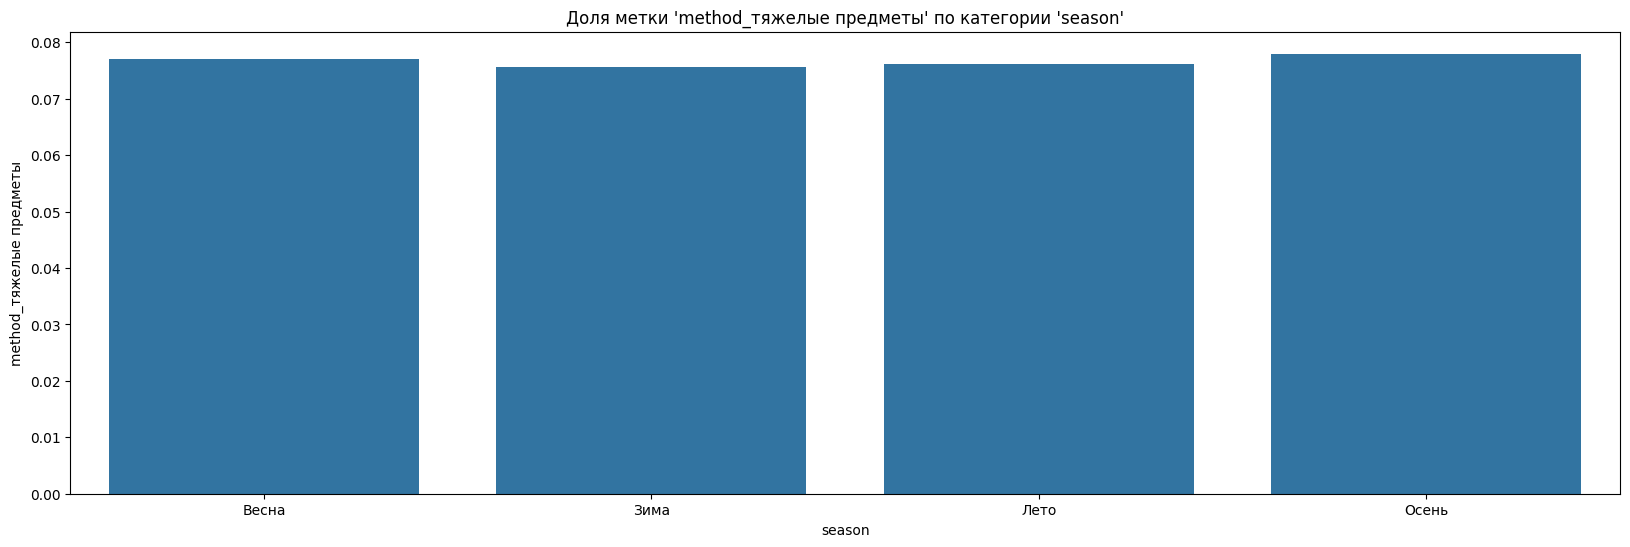

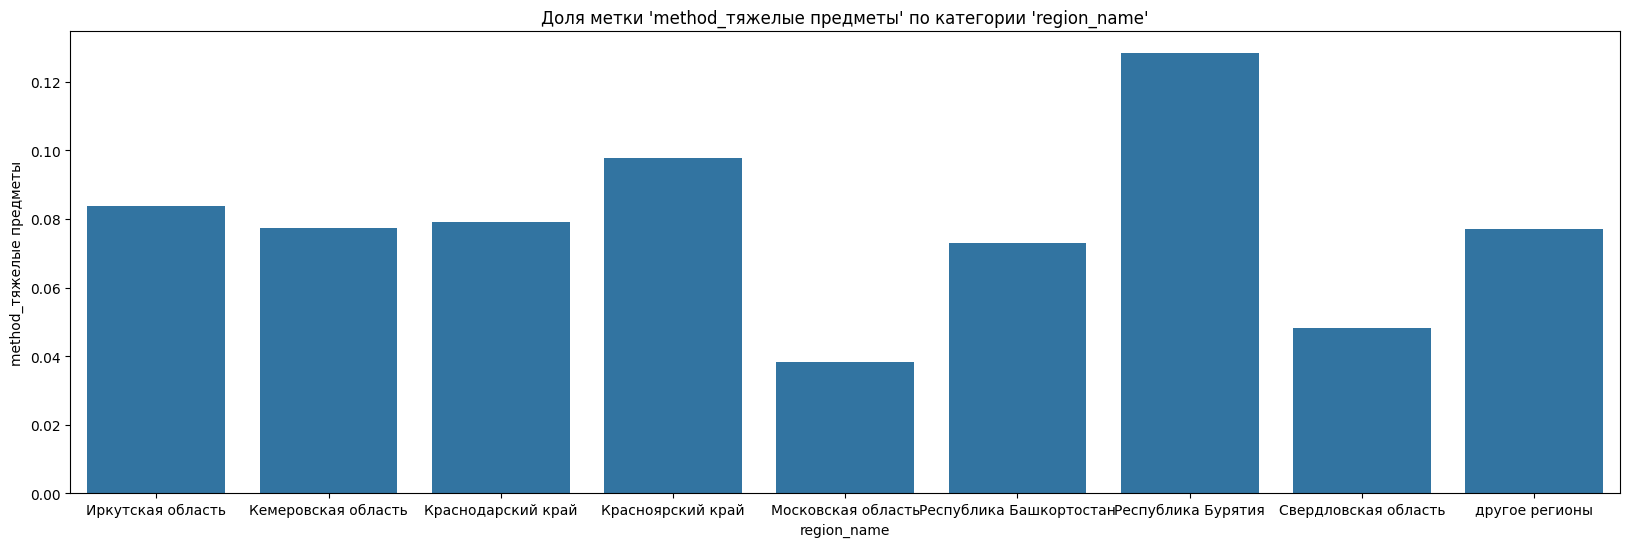

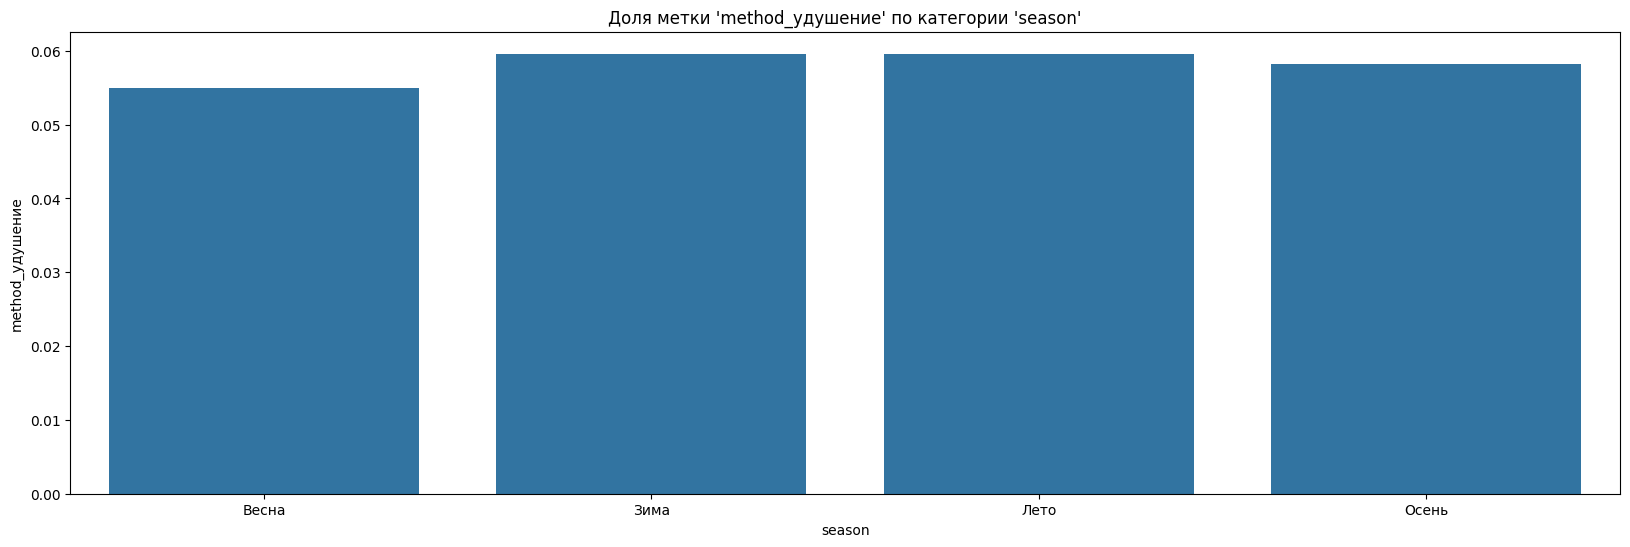

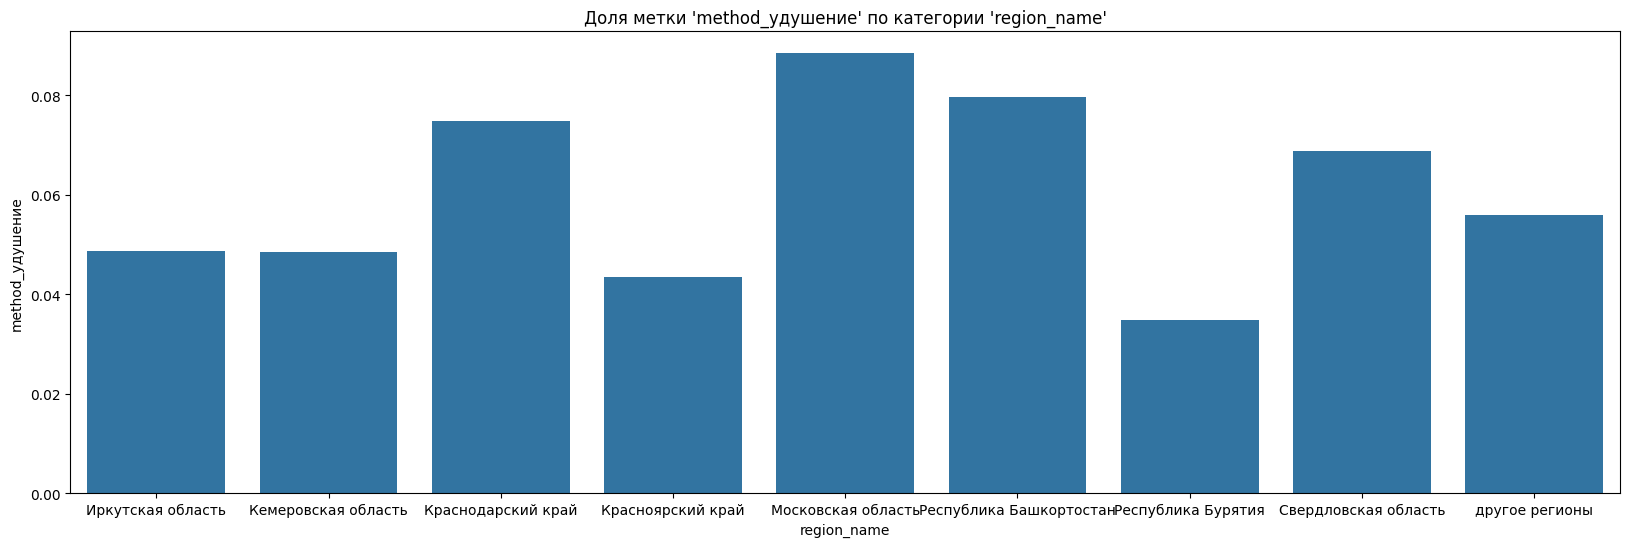

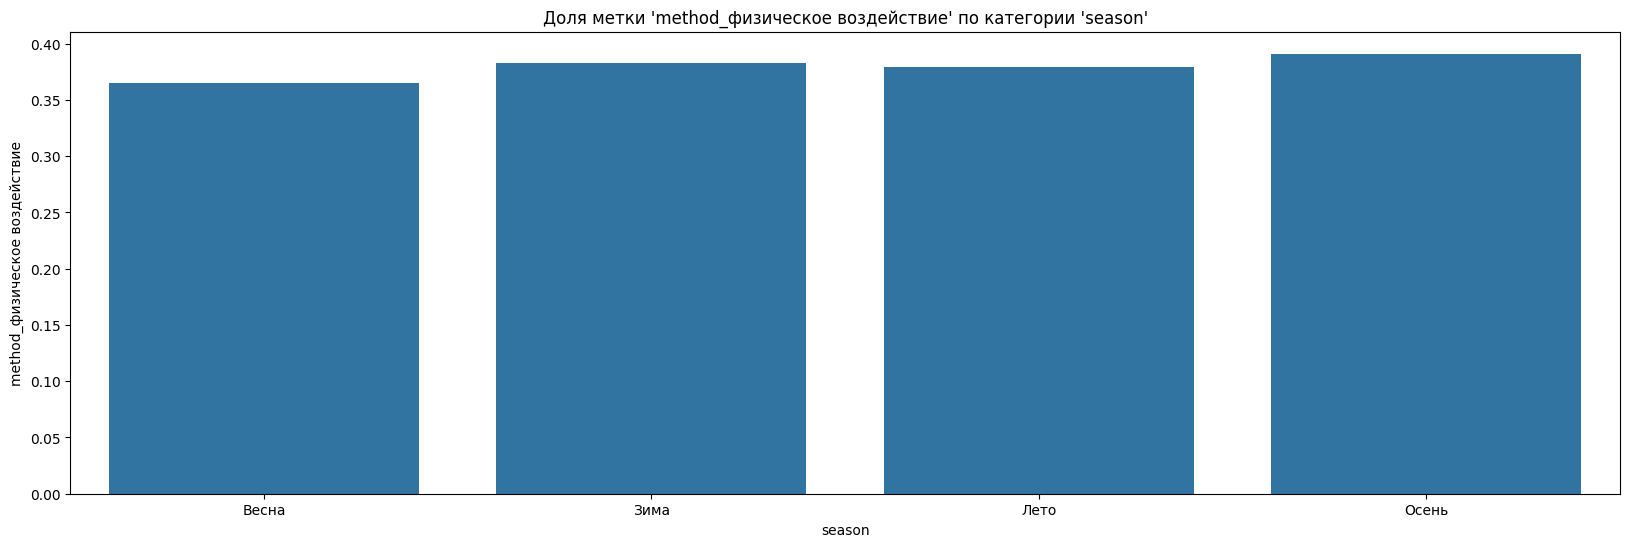

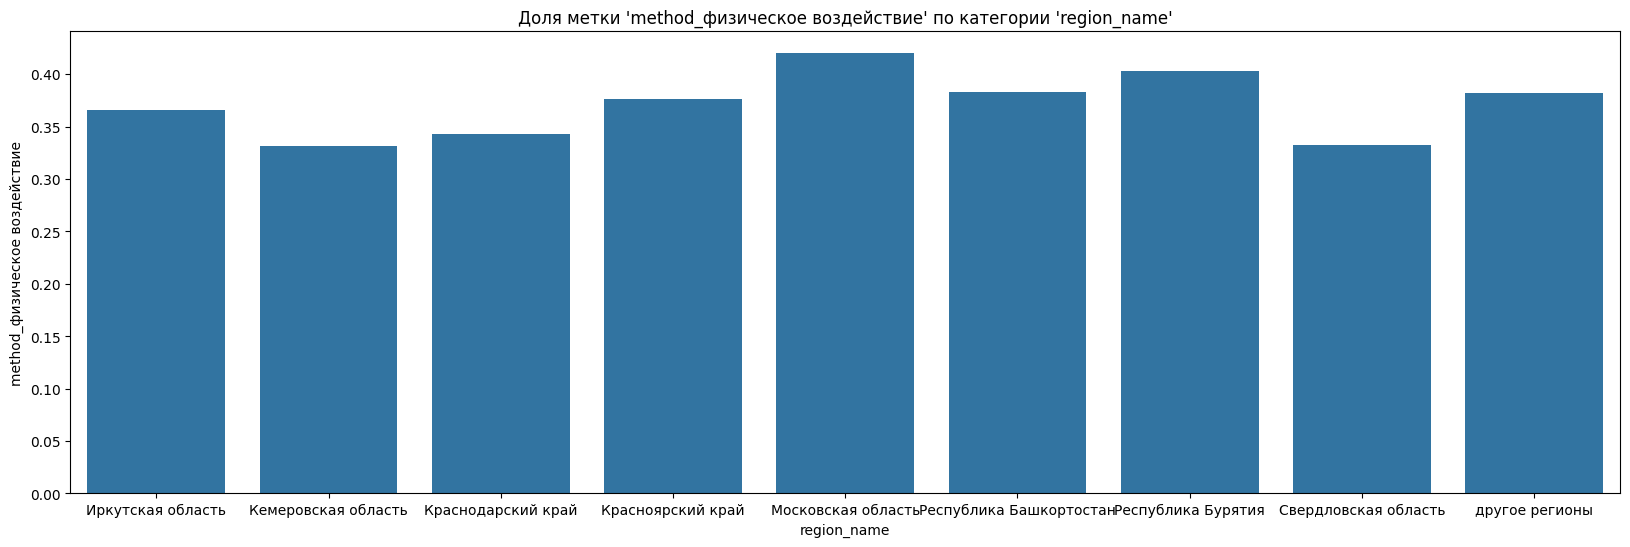

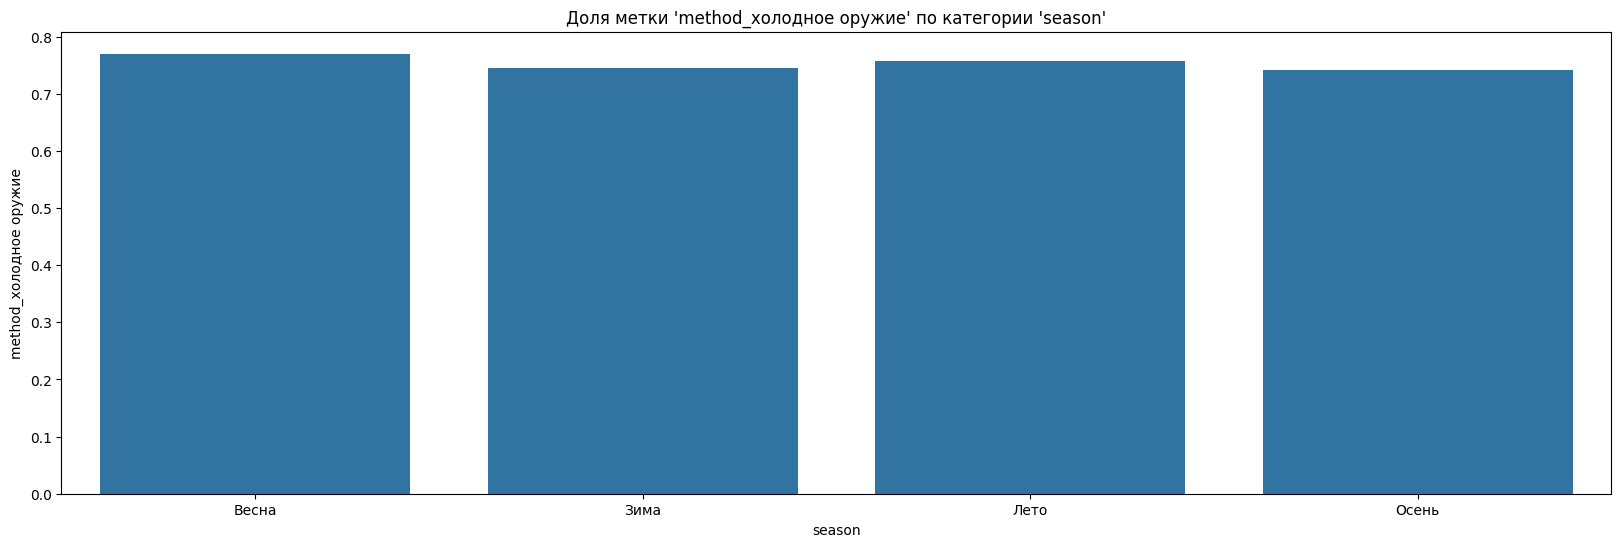

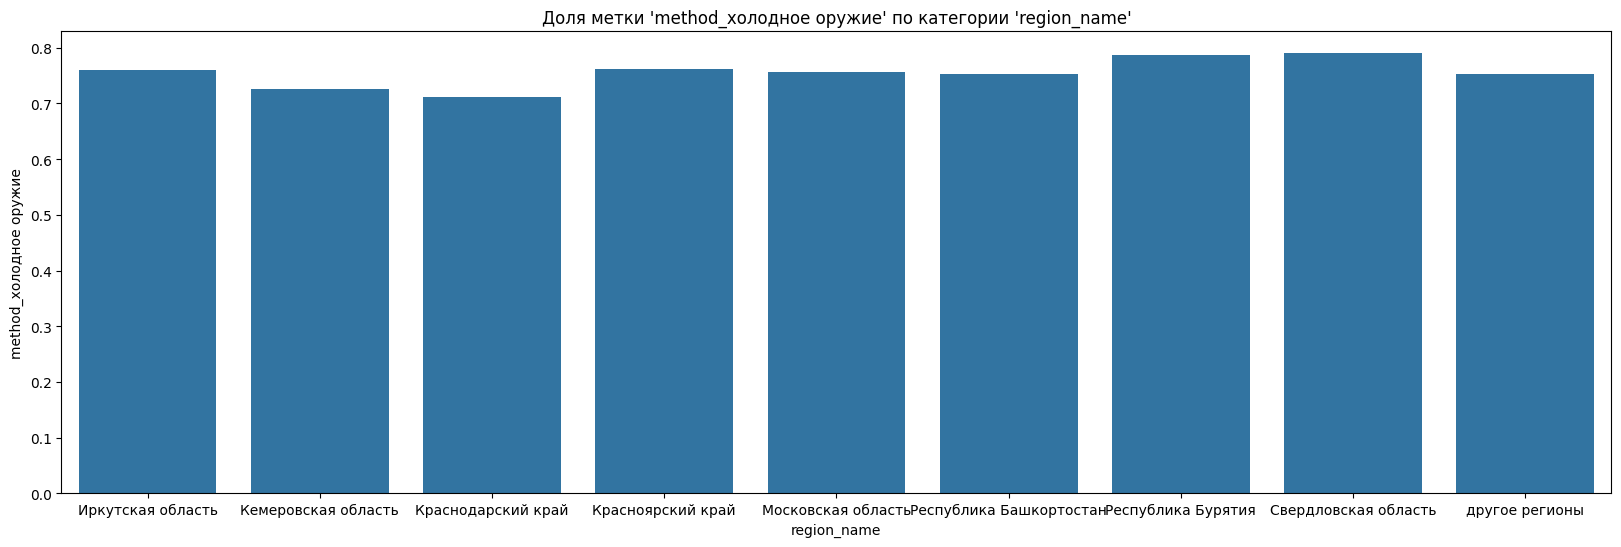

In [547]:
for label in mlb1.classes_:
    for categorical_feature in ['season', 'region_name']:
        label1 = f"method_{label}"
        grouped = df.groupby(categorical_feature)[label1].mean().reset_index()

        plt.figure(figsize=(20, 6))
        sns.barplot(x=categorical_feature, y=label1, data=grouped)
        plt.title(f"Доля метки '{label1}' по категории '{categorical_feature}'")
        plt.show()

In [548]:
df

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,prison_term,...,motive_насилие,motive_прочее,motive_ревность,location_другое,location_жилое помещение,location_общественное место,location_общественный транспорт,location_подъезд и прилегающие зоны,location_рабочая зона,location_уличное пространство
0,92093,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,0,1,9.000000,...,0,0,0,0,0,0,0,0,1,1
1,25775,другое судьи,Вынесен ПРИГОВОР,1,0,0,0,0,1,7.986857,...,0,0,0,0,0,1,0,0,0,1
2,75488,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,1,13.000000,...,0,0,0,0,1,0,0,0,0,0
3,126184,другое судьи,Вынесен ПРИГОВОР,0,0,1,1,0,1,13.000000,...,0,0,0,0,0,0,0,0,0,1
4,102316,другое судьи,Вынесен ПРИГОВОР,1,0,0,1,1,0,8.311355,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37564,6580,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,0,1,9.000000,...,0,0,0,0,1,0,0,0,0,0
37565,62712,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,1,0,9.000000,...,0,0,1,0,1,0,0,0,0,0
37566,54534,другое судьи,Вынесен ПРИГОВОР,1,0,1,0,1,1,3.830000,...,0,0,1,0,1,0,0,0,0,0
37567,47517,другое судьи,Вынесен ПРИГОВОР,1,0,1,1,1,1,21.000000,...,0,0,0,0,1,0,0,0,0,0


In [549]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'method1',
       'method_другое', 'method_огнестрельное оружие',
       'method_тяжелые предметы', 'method_удушение',
       'method_физическое воздействие', 'method_холодное оружие',
       'motive_алкоголь/наркотики', 'motive_аморальность', 'motive_другое',
       'motive_корысть', 'motive_личная неприязнь', 'motive_месть',
       'motive_насилие', 'motive_прочее', 'motive_ревность', 'location_другое',
       'location_жилое помещение', 'location_общественное место',
       'location_общественный транспорт',
       'location_подъезд и прилегающие зоны', 'location_рабочая зона',
       'location_уличное пространство'],
      dtype='object')

In [559]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna
from sklearn.preprocessing import StandardScaler

target_col = 'method'

categorical_features = ['decision', 'season', 'year', 'judge', 'region_name']
other_features = [
    'gender_accused', 'prior_convictions',
    'has_woman_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel',
    
    'motive_алкоголь/наркотики',
    'motive_аморальность', 'motive_корысть', 'motive_личная неприязнь',
    'motive_месть', 'motive_насилие', 'motive_прочее', 'motive_ревность',
    
    'location_другое', 'location_жилое помещение',
    'location_общественное место', 'location_общественный транспорт',
    'location_подъезд и прилегающие зоны', 'location_рабочая зона',
    'location_уличное пространство'
]

# selected_features = categorical_features + other_features + numeric_features
selected_features = categorical_features + other_features

mlb1 = MultiLabelBinarizer()

X = df[selected_features]
y = mlb1.fit_transform(df['method1'])

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),    
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [560]:
from optuna.importance import get_param_importances
from sklearn.multiclass import OneVsRestClassifier

def train_random_forest(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = OneVsRestClassifier(RandomForestClassifier(**params))
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        acc = accuracy_score(y_val, val_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_val, val_pred, average="micro", zero_division=0
        )
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=5)

    best_params = study.best_params
    print("Best RF Params")
    print(best_params)

    # importance = get_param_importances(study)
    # print("\nHyperparameter Importance for Random Forest")
    # for k, v in importance.items():
    #     print(f"{k}: {v:.4f}")

    final_model = OneVsRestClassifier(RandomForestClassifier(**best_params, random_state=42, n_jobs=-1))
    final_model.fit(
        np.vstack([X_train, X_val]),
        np.vstack([y_train, y_val])
    )
    test_pred = final_model.predict(X_test)

    print("\nRandom Forest Results")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, test_pred, average="micro", zero_division=0
    )
    print('Accuracy:', acc)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)

    importances_list = [estimator.feature_importances_ for estimator in final_model.estimators_]
    avg_importances = np.mean(importances_list, axis=0)
    feature_importance = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': avg_importances
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 20:40:29,232] A new study created in memory with name: no-name-9c2d074a-c539-4e50-baf2-d6565c2fe403
[I 2025-04-29 20:40:37,534] Trial 0 finished with value: 0.6529828706438275 and parameters: {'n_estimators': 322, 'max_depth': 3, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.6529828706438275.
[I 2025-04-29 20:41:13,592] Trial 1 finished with value: 0.6640625 and parameters: {'n_estimators': 889, 'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 1 with value: 0.6640625.
[I 2025-04-29 20:41:17,360] Trial 2 finished with value: 0.6628271487934679 and parameters: {'n_estimators': 155, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.6640625.
[I 2025-04-29 20:41:24,946] Trial 3 finished with value: 0.660340170815388 and parameters: {'n_estim

Best RF Params
{'n_estimators': 889, 'max_depth': 23, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': False}

Random Forest Results
Accuracy: 0.5066548358473825
Precision: 0.7456713492322771
Recall: 0.6003419253024724
F1: 0.6651610083054058

Random Forest Top 10
                                     Feature  Importance
36               remainder__has_woman_victim    0.096221
34                 remainder__gender_accused    0.095721
55  remainder__location_уличное пространство    0.092925
50       remainder__location_жилое помещение    0.075181
43                 remainder__motive_корысть    0.062469
38                        remainder__attempt    0.052990
40                          remainder__cruel    0.047382
44        remainder__motive_личная неприязнь    0.042960
37                   remainder__many_victims    0.035149
39       remainder__victim_child_or_helpless    0.031205


In [561]:
target_col = 'method'

categorical_features = []
other_features = [
    'has_woman_victim',
    'gender_accused',
    'location_уличное пространство',
    'location_жилое помещение',
    'motive_корысть',
]

# selected_features = categorical_features + other_features + numeric_features
selected_features = categorical_features + other_features

mlb1 = MultiLabelBinarizer()

X = df[selected_features]
y = mlb1.fit_transform(df['method1'])

X_test_val, X_train, y_test_val, y_train = train_test_split(
    X, y, 
    test_size=0.7, 
    random_state=42
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_val, y_test_val, 
    test_size=0.5, 
    random_state=42
)

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),    
], remainder='passthrough')


X_rf_train = column_transformer.fit_transform(X_train)
X_rf_val = column_transformer.transform(X_val)
X_rf_test = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

In [562]:
rf_model, rf_importance = train_random_forest(X_rf_train, y_train, X_rf_val, y_val, X_rf_test, y_test)
print("\nRandom Forest Top 10")
print(rf_importance.head(10))

[I 2025-04-29 20:43:47,590] A new study created in memory with name: no-name-464e97c4-d913-4cbf-b9e8-77f6b4a74917
[I 2025-04-29 20:44:31,341] Trial 0 finished with value: 0.6573539091640459 and parameters: {'n_estimators': 789, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.6573539091640459.
[I 2025-04-29 20:45:35,044] Trial 1 finished with value: 0.657506212542026 and parameters: {'n_estimators': 847, 'max_depth': 27, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 0.657506212542026.
[I 2025-04-29 20:46:09,276] Trial 2 finished with value: 0.6573539091640459 and parameters: {'n_estimators': 560, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': False}. Best is trial 1 with value: 0.657506212542026.
[I 2025-04-29 20:47:15,786] Trial 3 finished with value: 0.657506212542026 a

Best RF Params
{'n_estimators': 847, 'max_depth': 27, 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}

Random Forest Results
Accuracy: 0.5128660159716061
Precision: 0.7491710875331565
Recall: 0.5942924776433456
F1: 0.6628043414491053

Random Forest Top 10
                                    Feature  Importance
1                 remainder__gender_accused    0.257808
0               remainder__has_woman_victim    0.212204
2  remainder__location_уличное пространство    0.190919
3       remainder__location_жилое помещение    0.172328
4                 remainder__motive_корысть    0.166740
